# Week 1 & 2: Data Preprocessing and EDA

This notebook covers the tasks for Week 1 and 2 of the Machine Learning Project.

**Tasks:**
- Load the dataset
- Data Cleaning (Duplicates, Missing Values)
- Handling Outliers (Blood Pressure, Height, Weight)
- Feature Engineering (Age in Years, BMI)
- Exploratory Data Analysis (EDA)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set Plot Style
sns.set(style="whitegrid")

## 1. Load Data

In [3]:
# Adjust path as necessary. If the file is in a subdirectory 'cardio_train.csv', use that path.
# Based on project structure:
input_file = "cardio_train.csv/cardio_train.csv"
if not os.path.exists(input_file):
    input_file = "cardio_train.csv"

print(f"Loading data from {input_file}...")
df = pd.read_csv(input_file, sep=';')
print(f"Initial shape: {df.shape}")
df.head()

Loading data from cardio_train.csv/cardio_train.csv...
Initial shape: (70000, 13)


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


## 2. specific Data Cleaning: Duplicates

In [5]:
dup_count = df.duplicated().sum()
print(f"Duplicates found: {dup_count}")
if dup_count > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicates removed.")
else:
    print("No duplicates found.")

Duplicates found: 0
No duplicates found.


## 3. Feature Engineering: Conversions

In [7]:
# Convert Age (days) to Years
df['age_years'] = (df['age'] / 365.25).round(1)
df[['age', 'age_years']].head()

,age,age_years
0,18393,50.4
1,20228,55.4
2,18857,51.6
3,17623,48.2
4,17474,47.8


## 4. Handling Outliers

We remove unreasonable values for Blood Pressure, Height, and Weight.

In [9]:
# Blood Pressure (ap_hi: Systolic, ap_lo: Diastolic)
# Standard range assumption: ap_hi [60, 240], ap_lo [30, 160]
print("Removing blood pressure outliers...")
df = df[(df['ap_hi'] >= 60) & (df['ap_hi'] <= 240)]
df = df[(df['ap_lo'] >= 30) & (df['ap_lo'] <= 160)]

# Ensure ap_hi > ap_lo
df = df[df['ap_hi'] > df['ap_lo']]

# Height [140, 250], Weight [40, 200] roughly
# (Adjusted slightly from strict medical bounds to cover data variation)
df = df[(df['height'] >= 140) & (df['height'] <= 250)]
df = df[(df['weight'] >= 40)]

print(f"Shape after cleaning outliers: {df.shape}")

Removing blood pressure outliers...
Shape after cleaning outliers: (68484, 14)


## 5. Feature Engineering: BMI

In [11]:
df['bmi'] = df['weight'] / ((df['height'] / 100) ** 2)
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,bmi
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0,50.4,21.967120
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1,55.4,34.927679
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1,51.6,23.507805
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1,48.2,28.710479
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0,47.8,23.011177


## 6. Exploratory Data Analysis (EDA)

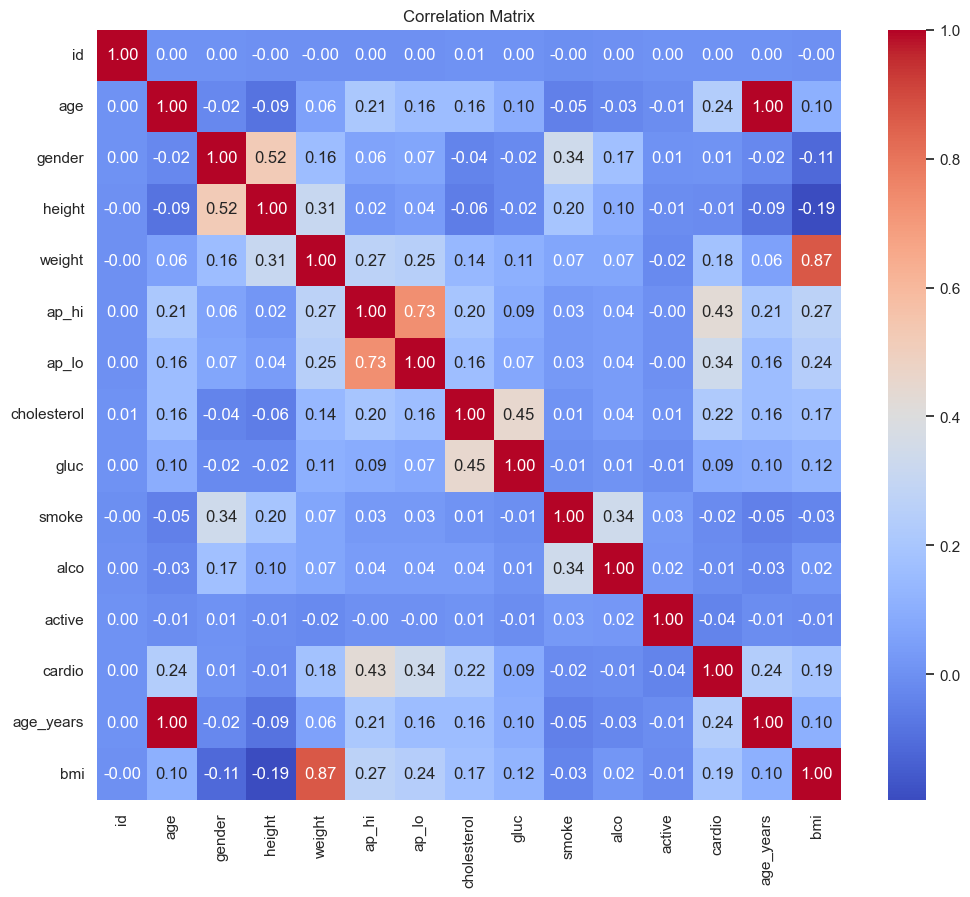

In [13]:
# Correlation Matrix
plt.figure(figsize=(12, 10))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title('Correlation Matrix')
plt.show()

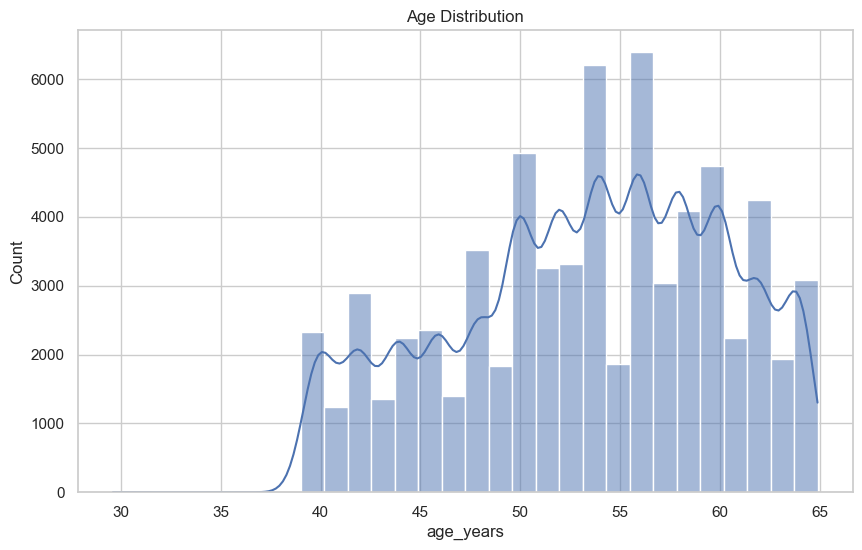

In [14]:
# Age Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['age_years'], bins=30, kde=True)
plt.title('Age Distribution')
plt.show()

## 7. Save Cleaned Data

In [16]:
# Drop 'id' column as it is not needed for modeling
if 'id' in df.columns:
    df.drop('id', axis=1, inplace=True)

output_file = "cardio_train_cleaned.csv"
df.to_csv(output_file, index=False)
print(f"Processed data saved to {output_file}")

Processed data saved to cardio_train_cleaned.csv
